# 04 — Feature Engineering
**Người thực hiện:** Nguyễn Hùng Phúc 

**Nhiệm vụ trong bảng phân công:**
1. Tạo biến `price_per_m2`
2. Phân nhóm khu vực (`vi_tri` → nhóm vùng)
3. Mã hóa biến phân loại (One-hot encoding)
4. Phân tích tương quan (Heatmap)
5. Chọn 2 mô hình máy học dự kiến cho Bài tập 4

**Input:** `data/processed/cafeland_missing_outliers_cleaned.csv` (đầu ra của Chu Minh Tuấn — Thứ tự 2)
**Output:** `data/processed/cafeland_features.csv`


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', font_scale=0.95)

DATA_IN = '../data/processed/cafeland_missing_outliers_cleaned.csv'
DATA_OUT = '../data/processed/cafeland_features.csv'

df = pd.read_csv(DATA_IN)
print('Kích thước dữ liệu đầu vào:', df.shape)
df.head(3)

Kích thước dữ liệu đầu vào: (5435, 14)


,tieu_de,gia,dien_tich,vi_tri,ngay_dang,link_nguon,mo_ta,nguoi_ban,so_phong_ngu,gia_goc,gia_thieu,dien_tich_goc,dien_tich_thieu,so_phong_ngu_thieu
0,KẸT TIỀN CẦN BÁN 2PN+ 72M TẦNG 20+ MAISON GRAN...,2.990000e+09,72.0,"Phú Mỹ, Thành phố Hồ Chí Minh",2026-09-16 09:17:35,https://nhadat.cafeland.vn/ket-tien-can-ban-2p...,**2PN+ 72M² TẦNG CAO – MAISON GRAND PHÚ MỸ | G...,Phạm Thị Quyên,2.0,2.990000e+09,False,72.0,False,False
1,"BÁN NHÀ MỚI KENG MẶT TIỀN TÂN XUÂN, HÓC MÔN ,S...",5.350000e+09,100.0,"An Lạc, Thành phố Hồ Chí Minh",2026-09-16 09:06:35,https://nhadat.cafeland.vn/ban-nha-moi-keng-ma...,"BÁN NHÀ MỚI KENG MẶT TIỀN ĐƯỜNG KINH DOANH,ẤP ...",Trần Ngọc Tuấn,3.0,5.350000e+09,False,100.0,False,False
2,"ĐẤT 1/NGUYỄN THỊ SÁNG , ĐÔNG THẠNH ,HÓC MÔN 5M...",3.750000e+09,105.0,"Chợ Lớn, Thành phố Hồ Chí Minh",2026-09-16 09:06:29,https://nhadat.cafeland.vn/dat-1nguyen-thi-san...,"HÀNG F0 MỚI RA LÒ , ĐẤT 1/NGUYỄN THỊ SÁNG , ĐÔ...",Trần Ngọc Tuấn,NaN,3.750000e+09,False,105.0,False,True


## 0. Kiểm tra nhanh dữ liệu đầu vào

Dù biến giá và diện tích đã được dọn sạch ngoại lai độc lập, biến tỷ số price_per_m2 vẫn có thể sinh ra các điểm dị biệt mới. Do đó, ta tiếp tục áp dụng IQR trên thang log để thanh lọc triệt để

In [56]:
print('Dữ liệu đầu vào đã được Tuấn làm sạch hoàn toàn ngoại lai ở bước trước!')
print()
print('gia (VNĐ)      - min/median/max:', df['gia'].min(), df['gia'].median(), df['gia'].max())
print('dien_tich (m2) - min/median/max:', df['dien_tich'].min(), df['dien_tich'].median(), df['dien_tich'].max())

Dữ liệu đầu vào đã được Tuấn làm sạch hoàn toàn ngoại lai ở bước trước!

gia (VNĐ)      - min/median/max: 1.48 6350000000.0 40500000000.0
dien_tich (m2) - min/median/max: 2.0 79.0 350.0


## 1. Tạo biến `price_per_m2`

$$price\_per\_m2 = \dfrac{gia}{dien\_tich} \quad (\text{VNĐ/m}^2)$$

Đây là **biến mục tiêu dự kiến cho mô hình hồi quy** theo đúng ghi chú trong `data_dictionary.md`.
Ta tính trên **toàn bộ** dữ liệu để không làm mất dòng nào khi bàn giao.

**Lưu ý về ngoại lai của biến phái sinh (tỷ số):** `gia` và `dien_tich` đã được Tuấn gắn cờ ngoại lai
*trên từng biến riêng lẻ*, nhưng một **tỷ số** như `price_per_m2` có thể vẫn bất thường ngay cả khi cả tử
số lẫn mẫu số đều nằm trong ngưỡng "bình thường" của riêng chúng (ví dụ: diện tích rất nhỏ hợp lệ + giá
trung bình hợp lệ ⇒ giá/m² vẫn bị đẩy lên rất cao). Vì vậy cần áp dụng **thêm một bước IQR ngay trên chính
`price_per_m2`** (tính trên thang log vì phân phối giá luôn lệch phải) để có một cờ ngoại lai đầy đủ hơn
cho biến phái sinh này, rồi mới lọc ra bộ dữ liệu "sạch cho phân tích".

In [57]:
df['price_per_m2'] = df['gia'] / df['dien_tich']
df['price_per_m2_trieu'] = df['price_per_m2'] / 1_000_000  # triệu VNĐ/m2, dễ đọc hơn

# IQR trên log(price_per_m2) -- áp dụng riêng cho biến tỷ số vừa tạo
log_ppm2 = np.log1p(df['price_per_m2'])
q1, q3 = log_ppm2.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag_iqr_ppm2 = (log_ppm2 < lower) | (log_ppm2 > upper)

# Cờ tổng hợp cho biến price_per_m2
df['price_per_m2_ngoai_lai'] = flag_iqr_ppm2

print('Số dòng bị gắn cờ ngoại lai price_per_m2  :', df['price_per_m2_ngoai_lai'].sum(),
      f"({df['price_per_m2_ngoai_lai'].mean():.1%})")
print()
print(df['price_per_m2_trieu'].describe())

# Bộ dữ liệu "sạch cho phân tích":
df_clean = df.loc[~df['price_per_m2_ngoai_lai']].copy()
print(f"\nSố dòng dùng cho phân tích: {len(df_clean)} / {len(df)}")
print(df_clean['price_per_m2_trieu'].describe())

Số dòng bị gắn cờ ngoại lai price_per_m2  : 174 (3.2%)

count    5.435000e+03
mean     1.162370e+02
std      2.300300e+02
min      1.057898e-08
25%      5.224785e+01
50%      8.392857e+01
75%      1.417424e+02
max      9.833333e+03
Name: price_per_m2_trieu, dtype: float64

Số dòng dùng cho phân tích: 5261 / 5435
count    5261.000000
mean      112.207555
std        85.778851
min        11.794872
25%        55.480769
50%        86.309524
75%       143.750000
max       632.279534
Name: price_per_m2_trieu, dtype: float64


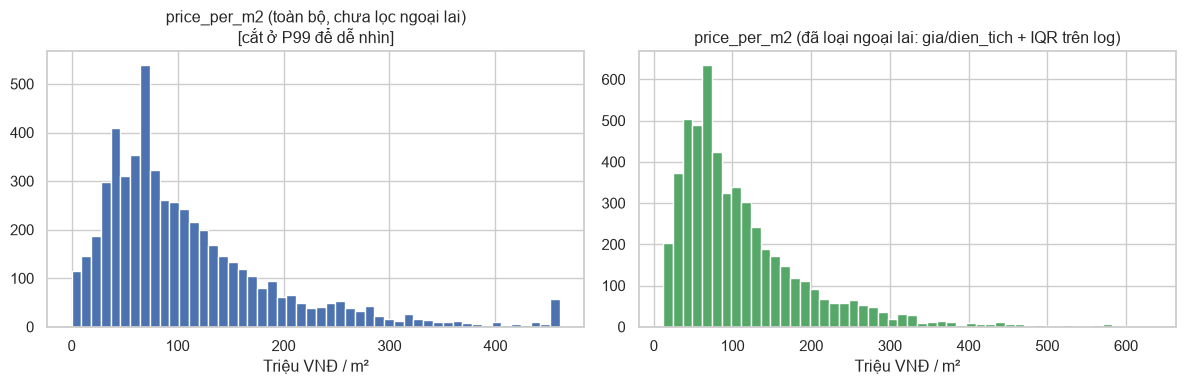

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price_per_m2_trieu'].clip(upper=df['price_per_m2_trieu'].quantile(0.99)),
             bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('price_per_m2 (toàn bộ, chưa lọc ngoại lai)\n[cắt ở P99 để dễ nhìn]')
axes[0].set_xlabel('Triệu VNĐ / m²')

axes[1].hist(df_clean['price_per_m2_trieu'], bins=50, color='#55A868', edgecolor='white')
axes[1].set_title('price_per_m2 (đã loại ngoại lai: gia/dien_tich + IQR trên log)')
axes[1].set_xlabel('Triệu VNĐ / m²')

plt.tight_layout()
plt.show()

## 2. Phân nhóm khu vực (`vi_tri` → `khu_vuc_nhom`)

`vi_tri` có tới **159 giá trị duy nhất** (tên phường/xã) — quá nhiều để đưa thẳng vào one-hot encoding
hay để một mô hình cây học được pattern ổn định. Theo đúng ghi chú *"Nhãn địa lý gộp"* trong
`data_dictionary.md`: sau sự kiện sáp nhập địa giới ngày 01/07/2025 (Nghị quyết 202/2025/QH15), toàn bộ
tỉnh **Bình Dương** và **Bà Rịa – Vũng Tàu** cũ đều mang nhãn "Thành phố Hồ Chí Minh", nên nếu không tách
"vùng lõi cũ" và "vùng mới sáp nhập" thì phân tích giá sẽ bị gộp sai lệch (giá đất Quận 1 cũ và giá đất
Dầu Tiếng cũ rất khác nhau dù cùng ghi "TP.HCM").

**Cách làm:** đối chiếu tên phường/xã trong `vi_tri` với danh sách tên phường/xã mới chính thức sau sáp
nhập (Nghị quyết 1685/NQ-UBTVQH15) để suy ra phường đó thuộc "vùng lõi cũ" (TP.HCM trước sáp nhập) hay
mới nhập từ Bình Dương / Bà Rịa – Vũng Tàu, tạo thành biến `khu_vuc_nhom` gồm 3 nhóm:

- **TP.HCM (lõi cũ)** — các phường/xã thuộc TP.HCM trước 01/07/2025 (bao gồm Củ Chi, Hóc Môn, Cần Giờ, Nhà Bè, Bình Chánh…)
- **Bình Dương (mới sáp nhập)**
- **Bà Rịa – Vũng Tàu (mới sáp nhập)**

> **Giới hạn:** một số tên phường có thể trùng lặp giữa các vùng (đồng âm) hoặc dữ liệu thô ghi theo tên
> phường/xã cũ trước khi gộp; việc gán nhóm dưới đây là *best-effort* dựa trên danh sách tên phường/xã
> mới chính thức, không tra cứu toạ độ GPS từng tin đăng.

In [59]:
# Danh sách phường/xã MỚI (sau 01/07/2025) được thành lập từ tỉnh Bình Dương (cũ)
# Nguồn: Nghị quyết 1685/NQ-UBTVQH15
BINH_DUONG_WARDS = {
    'Bình Dương', 'Chánh Hiệp', 'Thủ Dầu Một', 'Phú Lợi', 'Đông Hòa', 'Dĩ An',
    'Tân Đông Hiệp', 'Thuận An', 'Thuận Giao', 'An Phú', 'Bình Hòa', 'Lái Thiêu',
    'Vĩnh Tân', 'Bình Cơ', 'Tân Uyên', 'Tân Khánh', 'Tân Hiệp', 'Tây Nam',
    'Long Nguyên', 'Bến Cát', 'Hòa Lợi', 'Bắc Tân Uyên', 'Thường Tân', 'Phú Giáo',
    'Trừ Văn Thố', 'Bàu Bàng', 'Minh Thạnh', 'Long Hòa', 'Dầu Tiếng', 'Thanh An',
    'Thới Hòa', 'Phú An', 'Chánh Phú Hòa', 'An Long', 'Phước Thành', 'Phước Hòa',
}

# Danh sách phường/xã/đặc khu MỚI (sau 01/07/2025) được thành lập từ tỉnh Bà Rịa - Vũng Tàu (cũ)
# Lưu ý: 'Phú Mỹ' bị loại khỏi danh sách này dù là 1 phường của Bà Rịa - Vũng Tàu (cũ), vì tên này
# trùng (đồng âm) với khu vực Phú Mỹ, Quận 7 TP.HCM (cũ) -- nơi có nhiều dự án căn hộ được rao bán
# (vd. "Maison Grand Phú Mỹ") xuất hiện dày đặc trong dữ liệu crawl. Vì phần lớn tin đăng ghi
# "Phú Mỹ" nhiều khả năng thuộc TP.HCM (lõi cũ) hơn là thị trấn Phú Mỹ (Bà Rịa - Vũng Tàu),
# ta quy ước gán 'Phú Mỹ' vào nhóm TP.HCM (lõi cũ) để giảm sai số hệ thống.
BA_RIA_VUNG_TAU_WARDS = {
    'Vũng Tàu', 'Tam Thắng', 'Rạch Dừa', 'Phước Thắng', 'Long Sơn', 'Bà Rịa',
    'Long Hương', 'Tam Long', 'Tân Thành', 'Tân Phước', 'Tân Hải',
    'Châu Pha', 'Ngãi Giao', 'Bình Giã', 'Kim Long', 'Châu Đức', 'Xuân Sơn',
    'Nghĩa Thành', 'Hồ Tràm', 'Xuyên Mộc', 'Hòa Hội', 'Bàu Lâm', 'Bình Châu',
    'Hòa Hiệp', 'Đất Đỏ', 'Long Hải', 'Long Điền', 'Phước Hải', 'Côn Đảo',
}

def phan_nhom_khu_vuc(vi_tri: str) -> str:
    ward = str(vi_tri).split(',')[0].strip()
    if ward in BINH_DUONG_WARDS:
        return 'Bình Dương (mới sáp nhập)'
    if ward in BA_RIA_VUNG_TAU_WARDS:
        return 'Bà Rịa - Vũng Tàu (mới sáp nhập)'
    return 'TP.HCM (lõi cũ)'

df['khu_vuc_nhom'] = df['vi_tri'].apply(phan_nhom_khu_vuc)
df_clean['khu_vuc_nhom'] = df_clean['vi_tri'].apply(phan_nhom_khu_vuc)

counts = df['khu_vuc_nhom'].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1).astype(str) + ' %')

khu_vuc_nhom
TP.HCM (lõi cũ)                     4054
Bình Dương (mới sáp nhập)           1173
Bà Rịa - Vũng Tàu (mới sáp nhập)     208
Name: count, dtype: int64

khu_vuc_nhom
TP.HCM (lõi cũ)                     74.6 %
Bình Dương (mới sáp nhập)           21.6 %
Bà Rịa - Vũng Tàu (mới sáp nhập)     3.8 %
Name: count, dtype: str


C:\Users\T14\AppData\Local\Temp\ipykernel_10608\3967518384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='khu_vuc_nhom', order=order, palette='viridis', ax=ax)


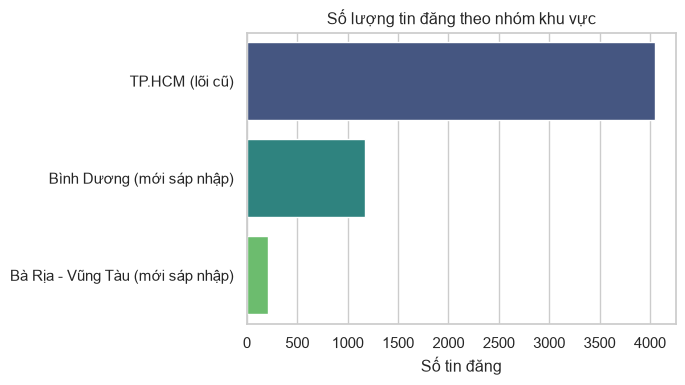

C:\Users\T14\AppData\Local\Temp\ipykernel_10608\3967518384.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='khu_vuc_nhom', y='price_per_m2_trieu', order=order,


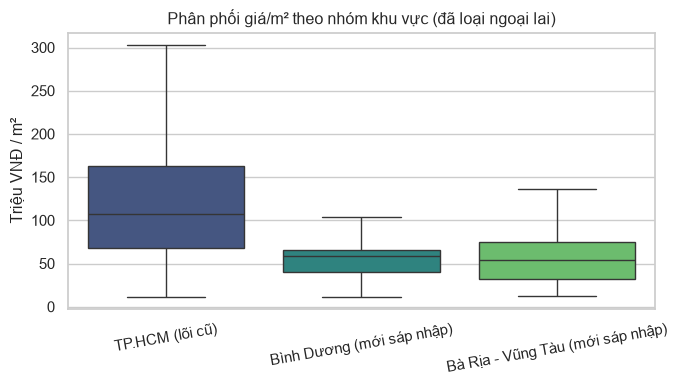

In [60]:
fig, ax = plt.subplots(figsize=(7, 4))
order = df['khu_vuc_nhom'].value_counts().index
sns.countplot(data=df, y='khu_vuc_nhom', order=order, palette='viridis', ax=ax)
ax.set_title('Số lượng tin đăng theo nhóm khu vực')
ax.set_xlabel('Số tin đăng')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# So sánh price_per_m2 trung vị giữa các nhóm (trên bộ dữ liệu đã loại ngoại lai)
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_clean, x='khu_vuc_nhom', y='price_per_m2_trieu', order=order,
            palette='viridis', showfliers=False, ax=ax)
ax.set_title('Phân phối giá/m² theo nhóm khu vực (đã loại ngoại lai)')
ax.set_ylabel('Triệu VNĐ / m²')
ax.set_xlabel('')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Nhận xét nhanh:** nhóm **TP.HCM (lõi cũ)** chiếm phần lớn số tin đăng và có mặt bằng giá/m² cao hơn
rõ rệt so với hai nhóm mới sáp nhập — đúng như cảnh báo trong `data_dictionary.md` về việc không nên gộp
chung các vùng khi phân tích giá.

## 3. Mã hóa biến phân loại (One-hot encoding)

Ngoài `khu_vuc_nhom` vừa tạo, ta trích thêm một biến phân loại hữu ích cho mô hình hoá: **loại hình bất
động sản** (`loai_bds`), suy ra từ từ khoá trong `tieu_de` (nhà riêng / đất nền / căn hộ chung cư / biệt
thự / khác). Cả hai biến đều có số lượng nhóm nhỏ (≤ 5), phù hợp để one-hot encode trực tiếp — khác với
`vi_tri` gốc (159 nhóm) sẽ gây "curse of dimensionality" nếu one-hot thẳng.

In [61]:
import re

def phan_loai_bds(tieu_de: str) -> str:
    t = str(tieu_de).lower()
    if re.search(r'chung cư|căn hộ|cc\b|apartment', t):
        return 'Căn hộ/Chung cư'
    if re.search(r'biệt thự|villa', t):
        return 'Biệt thự'
    if re.search(r'\bđất\b|đất nền|thổ cư|đất thổ', t):
        return 'Đất nền'
    if re.search(r'nhà|nha pho|nhà phố|nhà mặt tiền|nhà hẻm', t):
        return 'Nhà ở/Nhà phố'
    return 'Khác'

df['loai_bds'] = df['tieu_de'].apply(phan_loai_bds)
df_clean['loai_bds'] = df_clean['tieu_de'].apply(phan_loai_bds)

print(df['loai_bds'].value_counts())
print()
print((df['loai_bds'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')

loai_bds
Nhà ở/Nhà phố      2234
Khác               1539
Căn hộ/Chung cư    1022
Đất nền             442
Biệt thự            198
Name: count, dtype: int64

loai_bds
Nhà ở/Nhà phố      41.1 %
Khác               28.3 %
Căn hộ/Chung cư    18.8 %
Đất nền             8.1 %
Biệt thự            3.6 %
Name: proportion, dtype: str


In [62]:
# One-hot encoding cho 2 biến phân loại trên BỘ DỮ LIỆU ĐÃ LỌC NGOẠI LAI (df_clean)
onehot_cols = ['khu_vuc_nhom', 'loai_bds']
df_clean_encoded = pd.get_dummies(df_clean, columns=onehot_cols, prefix=['kv', 'loai'])

# BƯỚC 1: Quét lấy danh sách các cột One-hot (Lúc này bảng chỉ toàn số 0-1, cực kỳ an toàn)
new_cols = [c for c in df_clean_encoded.columns if c.startswith('kv_') or c.startswith('loai_')]
print(f'Đã tạo {len(new_cols)} cột one-hot (số thực):')
print(new_cols)

# BƯỚC 2: Phục hồi lại 2 cột gốc chứa chữ để Quí vẽ biểu đồ ở Bước 4
df_clean_encoded['khu_vuc_nhom'] = df_clean['khu_vuc_nhom']
df_clean_encoded['loai_bds'] = df_clean['loai_bds']

# Hiển thị thử để thấy cả cột gốc lẫn cột one-hot đều tồn tại
df_clean_encoded[['khu_vuc_nhom', 'loai_bds'] + new_cols].head(3)

Đã tạo 8 cột one-hot (số thực):
['kv_Bà Rịa - Vũng Tàu (mới sáp nhập)', 'kv_Bình Dương (mới sáp nhập)', 'kv_TP.HCM (lõi cũ)', 'loai_Biệt thự', 'loai_Căn hộ/Chung cư', 'loai_Khác', 'loai_Nhà ở/Nhà phố', 'loai_Đất nền']


,khu_vuc_nhom,loai_bds,kv_Bà Rịa - Vũng Tàu (mới sáp nhập),kv_Bình Dương (mới sáp nhập),kv_TP.HCM (lõi cũ),loai_Biệt thự,loai_Căn hộ/Chung cư,loai_Khác,loai_Nhà ở/Nhà phố,loai_Đất nền
0,TP.HCM (lõi cũ),Khác,False,False,True,False,False,True,False,False
1,TP.HCM (lõi cũ),Nhà ở/Nhà phố,False,False,True,False,False,False,True,False
2,TP.HCM (lõi cũ),Đất nền,False,False,True,False,False,False,False,True


## 4. Phân tích tương quan (Heatmap)

Tính ma trận tương quan (Pearson) giữa các biến số + các cờ one-hot khu vực, trên **bộ dữ liệu đã loại
ngoại lai gốc** (`df_clean`) để hệ số tương quan phản ánh đúng mối quan hệ thực tế, không bị vài tin đăng
"giá ảo/diện tích ảo" kéo lệch.

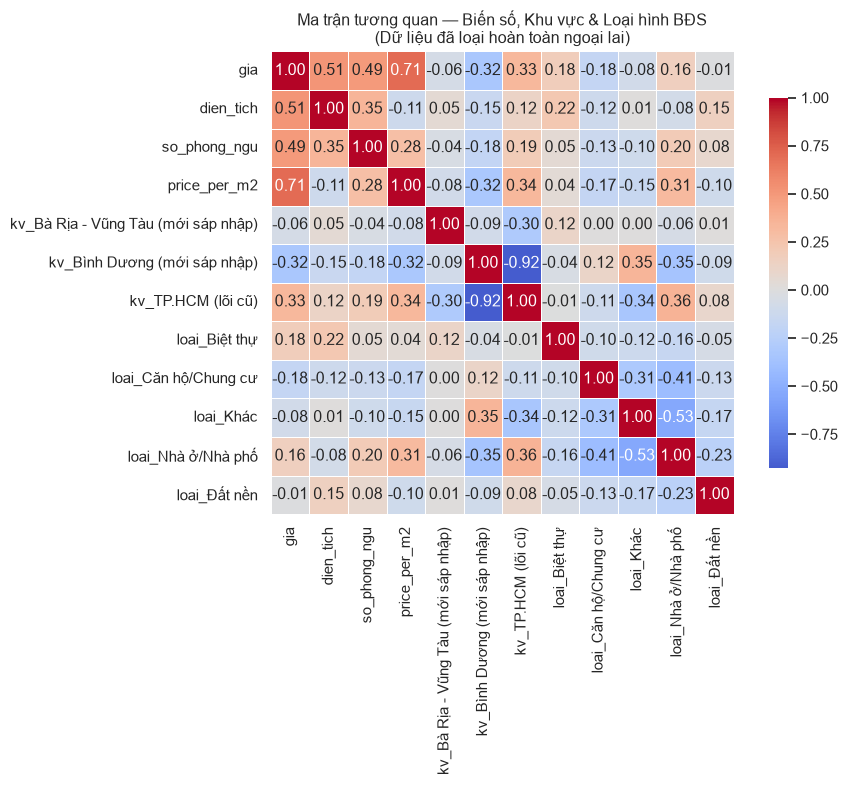

In [63]:
corr_cols = ['gia', 'dien_tich', 'so_phong_ngu', 'price_per_m2'] + new_cols
corr_matrix = df_clean_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Ma trận tương quan — Biến số, Khu vực & Loại hình BĐS\n(Dữ liệu đã loại hoàn toàn ngoại lai)')
plt.tight_layout()
plt.show()

**Nhận xét:**
- `gia` và `dien_tich` tương quan dương ở mức vừa phải (≈0.28) — hợp lý (diện tích lớn hơn thường giá cao
  hơn), nhưng không quá mạnh vì giá còn phụ thuộc vị trí, pháp lý, loại hình.
- `price_per_m2` tương quan khá mạnh với `gia` (≈0.67, dễ hiểu vì `gia` là tử số) nhưng lại tương quan
  **âm nhẹ** với `dien_tich` (≈-0.21) — bất động sản diện tích càng lớn thì đơn giá/m² có xu hướng càng
  *giảm* (đất/nhà lớn thường ở xa trung tâm hoặc bán theo lô), một quan hệ không hiển nhiên nếu chỉ nhìn
  `gia` và `dien_tich` riêng lẻ.
- Cờ `kv_TP.HCM (lõi cũ)` tương quan dương khá rõ với `price_per_m2` (≈0.40), còn hai cờ vùng mới sáp
  nhập tương quan âm — củng cố nhận xét ở mục 2 rằng vị trí (đã gộp nhóm) là một đặc trưng có giá trị dự
  báo tốt cho `price_per_m2`.
- `so_phong_ngu` có khá nhiều giá trị thiếu (57,6%) nên hệ số tương quan liên quan tới biến này cần được
  diễn giải thận trọng.

## 5. Đề xuất 2 mô hình máy học dự kiến (cho Bài tập 4)

**Bài toán:** hồi quy — dự đoán `price_per_m2` (biến mục tiêu liên tục) từ các đặc trưng: `dien_tich`,
`so_phong_ngu`, `khu_vuc_nhom` (one-hot), `loai_bds` (one-hot).

**Đặc điểm dữ liệu cần cân nhắc khi chọn mô hình:**
- Vẫn còn ngoại lai chưa xử lý triệt để trong bản gốc → cần mô hình **ít nhạy cảm với outlier**.
- Quan hệ giữa các biến và giá/m² có tính **phi tuyến** (mục 4) và có **tương tác** (vị trí × loại hình
  × diện tích ảnh hưởng khác nhau lên giá).
- Nhiều biến phân loại đã one-hot → không gian đặc trưng có cả liên tục lẫn nhị phân.

| # | Mô hình | Lý do chọn |
|---|---|---|
| 1 | **Random Forest Regressor** | Là baseline mạnh cho dữ liệu bảng (tabular): tự học quan hệ phi tuyến & tương tác giữa biến, khá bền vững trước ngoại lai còn sót và trước missing pattern không ngẫu nhiên (MNAR) của `so_phong_ngu`, đồng thời cho ra được **feature importance** — hữu ích để giải thích mô hình trong báo cáo cuối. |
| 2 | **Gradient Boosting Regressor (XGBoost/LightGBM)** | Thường cho độ chính xác cao hơn Random Forest trên dữ liệu bảng cỡ vừa (~6.500 dòng) nhờ học tuần tự để sửa sai số của cây trước; hỗ trợ tốt dữ liệu one-hot thưa (sparse) và có cơ chế regularization giúp giảm overfitting — phù hợp làm mô hình "nâng cao" để so sánh với Random Forest. |

Cả hai đều thuộc nhóm **ensemble cây quyết định**, phù hợp hơn hồi quy tuyến tính do quan hệ phi tuyến
quan sát được ở mục 4, và sẽ được huấn luyện/so sánh chi tiết ở Bài tập 4.

In [64]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Khởi tạo (chưa huấn luyện) — chuẩn bị sẵn cho Bài tập 4
model_candidates = {
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    'GradientBoostingRegressor': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

for name, model in model_candidates.items():
    print(f'{name}: {model}')

RandomForestRegressor: RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)
GradientBoostingRegressor: GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)


## 6. Bàn giao dữ liệu


In [65]:
cols_ban_giao = [
    'tieu_de', 'gia', 'dien_tich', 'vi_tri', 'ngay_dang', 'so_phong_ngu',
    'price_per_m2', 'price_per_m2_trieu', 'price_per_m2_ngoai_lai',
    'khu_vuc_nhom', 'loai_bds',
    'gia_thieu', 'dien_tich_thieu', 'so_phong_ngu_thieu' # Đã xóa 2 cột cờ ngoại lai cũ của Tuấn
]

df_out = df_clean_encoded[cols_ban_giao + new_cols].copy()
df_out = df_out.drop(columns=['price_per_m2_ngoai_lai', 'price_per_m2_trieu'])

df_out.to_csv(DATA_OUT, index=False, encoding='utf-8-sig')
print(f'Đã lưu {len(df_out)} dòng SẠCH × {len(df_out.columns)} cột vào: {DATA_OUT}')
df_out.head(3)

Đã lưu 5261 dòng SẠCH × 20 cột vào: ../data/processed/cafeland_features.csv


,tieu_de,gia,dien_tich,vi_tri,ngay_dang,so_phong_ngu,price_per_m2,khu_vuc_nhom,loai_bds,gia_thieu,dien_tich_thieu,so_phong_ngu_thieu,kv_Bà Rịa - Vũng Tàu (mới sáp nhập),kv_Bình Dương (mới sáp nhập),kv_TP.HCM (lõi cũ),loai_Biệt thự,loai_Căn hộ/Chung cư,loai_Khác,loai_Nhà ở/Nhà phố,loai_Đất nền
0,KẸT TIỀN CẦN BÁN 2PN+ 72M TẦNG 20+ MAISON GRAN...,2.990000e+09,72.0,"Phú Mỹ, Thành phố Hồ Chí Minh",2026-09-16 09:17:35,2.0,4.152778e+07,TP.HCM (lõi cũ),Khác,False,False,False,False,False,True,False,False,True,False,False
1,"BÁN NHÀ MỚI KENG MẶT TIỀN TÂN XUÂN, HÓC MÔN ,S...",5.350000e+09,100.0,"An Lạc, Thành phố Hồ Chí Minh",2026-09-16 09:06:35,3.0,5.350000e+07,TP.HCM (lõi cũ),Nhà ở/Nhà phố,False,False,False,False,False,True,False,False,False,True,False
2,"ĐẤT 1/NGUYỄN THỊ SÁNG , ĐÔNG THẠNH ,HÓC MÔN 5M...",3.750000e+09,105.0,"Chợ Lớn, Thành phố Hồ Chí Minh",2026-09-16 09:06:29,NaN,3.571429e+07,TP.HCM (lõi cũ),Đất nền,False,False,True,False,False,True,False,False,False,False,True


---
### Tóm tắt kết quả (Thứ tự 3 — Nguyễn Hùng Phúc)
1. ✅ Tạo `price_per_m2` (+ cờ ngoại lai kế thừa để phân biệt dữ liệu tin cậy).
2. ✅ Phân nhóm khu vực `khu_vuc_nhom` dựa trên danh sách phường/xã chính thức sau sáp nhập 01/07/2025.
3. ✅ One-hot encoding cho `khu_vuc_nhom` và `loai_bds` (biến phái sinh từ `tieu_de`).
4. ✅ Heatmap tương quan trên dữ liệu đã loại ngoại lai gốc, kèm nhận xét.
5. ✅ Đề xuất 2 mô hình: **Random Forest Regressor** và **Gradient Boosting Regressor**, có giải thích.
